In [1]:
from google.colab import files

In [2]:
uploaded = files.upload()

Saving nasa_exoplanet_intelligence.csv to nasa_exoplanet_intelligence.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

In [5]:
nasa_df = pd.read_csv("nasa_exoplanet_intelligence.csv")

In [6]:
nasa_df.head()

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)


In [8]:
nasa_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           6150 non-null   object 
 1   host_star             6150 non-null   object 
 2   n_stars               6150 non-null   int64  
 3   n_planets             6150 non-null   int64  
 4   discovery_method      6150 non-null   object 
 5   disc_year             6149 non-null   float64
 6   disc_facility         6150 non-null   object 
 7   orbital_period_days   5816 non-null   float64
 8   planet_radius_earth   6100 non-null   float64
 9   planet_mass_earth     6119 non-null   float64
 10  equilibrium_temp_k    4587 non-null   float64
 11  orbital_eccentricity  5212 non-null   float64
 12  semi_major_axis_au    5834 non-null   float64
 13  star_temp_k           5860 non-null   float64
 14  star_radius_sun       5836 non-null   float64
 15  star_mass_sun        

In [9]:
nasa_df.describe().T

,count,mean,std,min,25%,50%,75%,max
n_stars,6150.0,1.103740,3.430925e-01,1.000000,1.000000,1.000000,1.000000,4.000000e+00
n_planets,6150.0,1.774309,1.158362e+00,1.000000,1.000000,1.000000,2.000000,8.000000e+00
disc_year,6149.0,2016.986339,4.964920e+00,1992.000000,2014.000000,2016.000000,2021.000000,2.026000e+03
orbital_period_days,5816.0,73594.206576,5.273718e+06,0.090706,4.347374,11.125222,39.762740,4.020000e+08
planet_radius_earth,6100.0,5.841983,5.436387e+00,0.309800,1.820750,2.840000,11.990000,8.720587e+01
planet_mass_earth,6119.0,406.787994,1.142866e+03,0.020000,4.190000,9.270000,190.849000,9.534852e+03
equilibrium_temp_k,4587.0,912.895472,4.642711e+02,34.000000,566.000000,818.000000,1164.000000,4.050000e+03
orbital_eccentricity,5212.0,0.079236,1.528807e-01,0.000000,0.000000,0.000000,0.091000,9.500000e-01
semi_major_axis_au,5834.0,15.718494,3.490439e+02,0.004400,0.052300,0.102015,0.307750,1.900000e+04
star_temp_k,5860.0,5398.163985,1.747460e+03,415.000000,4904.750000,5546.000000,5900.000000,5.700000e+04


In [10]:
nasa_df["planet_type"].value_counts()

,count
planet_type,
Mini-Neptune,2148
Gas Giant,1734
Super-Earth,1185
Neptune-like,479
Super-Jupiter,324
Sub-Earth,230
Unknown,50


In [12]:
pd.crosstab(
    nasa_df["planet_type"],
    nasa_df["habitable_zone_flag"],
    normalize="index"
).round(3) * 100

habitable_zone_flag,False,True
planet_type,,
Gas Giant,96.3,3.7
Mini-Neptune,90.5,9.5
Neptune-like,92.1,7.9
Sub-Earth,95.7,4.3
Super-Earth,93.0,7.0
Super-Jupiter,99.7,0.3
Unknown,98.0,2.0


In [13]:
nasa_df.groupby("planet_type")["equilibrium_temp_k"].median().sort_values()

,equilibrium_temp_k
planet_type,
Unknown,639.8
Mini-Neptune,678.0
Neptune-like,707.5
Super-Earth,923.0
Sub-Earth,994.5
Gas Giant,1055.0
Super-Jupiter,1700.0


In [14]:
nasa_df.groupby("planet_type")[[
    "planet_radius_earth",
    "planet_mass_earth",
    "equilibrium_temp_k",
    "orbital_period_days",
    "semi_major_axis_au"
]].median().sort_values("planet_radius_earth")

,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_period_days,semi_major_axis_au
planet_type,,,,,
Sub-Earth,0.840000,0.615000,994.5,3.916339,0.046040
Super-Earth,1.400000,2.600000,923.0,5.341853,0.056890
Mini-Neptune,2.460000,6.855000,678.0,13.767102,0.110000
Neptune-like,4.190000,16.350000,707.5,19.497157,0.159100
Gas Giant,12.600000,458.627538,1055.0,127.706905,0.843000
Super-Jupiter,15.984017,325.291555,1700.0,3.446459,0.049350
Unknown,NaN,1708.645516,639.8,16.812400,0.143135


In [16]:
planet_type_notes_df = pd.DataFrame({
    "planet_type": [
        "Sub-Earth",
        "Super-Earth",
        "Mini-Neptune",
        "Neptune-like",
        "Gas Giant",
        "Super-Jupiter",
        "Unknown"
    ],
    "tipik_yorum": [
        "Küçük, düşük kütleli, yıldızına çok yakın, kısa yörüngeli.",
        "Dünya'dan büyük, yine kısa yörüngeli ve sıcak.",
        "Super-Earth'ten büyük, daha uzun yörüngeli ve daha düşük median sıcaklıklı.",
        "Daha büyük ve ağır, Neptün benzeri profil.",
        "Çok büyük yarıçaplı, çok yüksek kütleli, daha uzun yörüngeli.",
        "Dev sınıf; tabloda çok sıcak ve kısa yörüngeli görünüyor.",
        "Bazı fiziksel değerleri eksik olabilir; model/evaluation tarafında dikkatli yorumlanmalı."
    ]
})

planet_type_notes_df

,planet_type,tipik_yorum
0,Sub-Earth,"Küçük, düşük kütleli, yıldızına çok yakın, kıs..."
1,Super-Earth,"Dünya'dan büyük, yine kısa yörüngeli ve sıcak."
2,Mini-Neptune,"Super-Earth'ten büyük, daha uzun yörüngeli ve ..."
3,Neptune-like,"Daha büyük ve ağır, Neptün benzeri profil."
4,Gas Giant,"Çok büyük yarıçaplı, çok yüksek kütleli, daha ..."
5,Super-Jupiter,Dev sınıf; tabloda çok sıcak ve kısa yörüngeli...
6,Unknown,Bazı fiziksel değerleri eksik olabilir; model/...


In [17]:
profile_features = [
    "planet_radius_earth",
    "planet_mass_earth",
    "equilibrium_temp_k",
    "orbital_period_days",
    "semi_major_axis_au"
]

planet_type_profile_df = (
    nasa_df
    .groupby("planet_type")[profile_features]
    .median()
    .reset_index()
    .sort_values("planet_radius_earth")
)

planet_type_profile_df

,planet_type,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_period_days,semi_major_axis_au
3,Sub-Earth,0.840000,0.615000,994.5,3.916339,0.046040
4,Super-Earth,1.400000,2.600000,923.0,5.341853,0.056890
1,Mini-Neptune,2.460000,6.855000,678.0,13.767102,0.110000
2,Neptune-like,4.190000,16.350000,707.5,19.497157,0.159100
0,Gas Giant,12.600000,458.627538,1055.0,127.706905,0.843000
5,Super-Jupiter,15.984017,325.291555,1700.0,3.446459,0.049350
6,Unknown,NaN,1708.645516,639.8,16.812400,0.143135


In [18]:
planet_type_info_df = planet_type_profile_df.merge(
    planet_type_notes_df,
    on="planet_type",
    how="left"
)

planet_type_info_df

,planet_type,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_period_days,semi_major_axis_au,tipik_yorum
0,Sub-Earth,0.840000,0.615000,994.5,3.916339,0.046040,"Küçük, düşük kütleli, yıldızına çok yakın, kıs..."
1,Super-Earth,1.400000,2.600000,923.0,5.341853,0.056890,"Dünya'dan büyük, yine kısa yörüngeli ve sıcak."
2,Mini-Neptune,2.460000,6.855000,678.0,13.767102,0.110000,"Super-Earth'ten büyük, daha uzun yörüngeli ve ..."
3,Neptune-like,4.190000,16.350000,707.5,19.497157,0.159100,"Daha büyük ve ağır, Neptün benzeri profil."
4,Gas Giant,12.600000,458.627538,1055.0,127.706905,0.843000,"Çok büyük yarıçaplı, çok yüksek kütleli, daha ..."
5,Super-Jupiter,15.984017,325.291555,1700.0,3.446459,0.049350,Dev sınıf; tabloda çok sıcak ve kısa yörüngeli...
6,Unknown,NaN,1708.645516,639.8,16.812400,0.143135,Bazı fiziksel değerleri eksik olabilir; model/...


In [20]:
planet_type_info_df.to_json(
    "planet_type_info.json",
    orient="records",
    force_ascii=False,
    indent=4
)

# VISUALIZATION


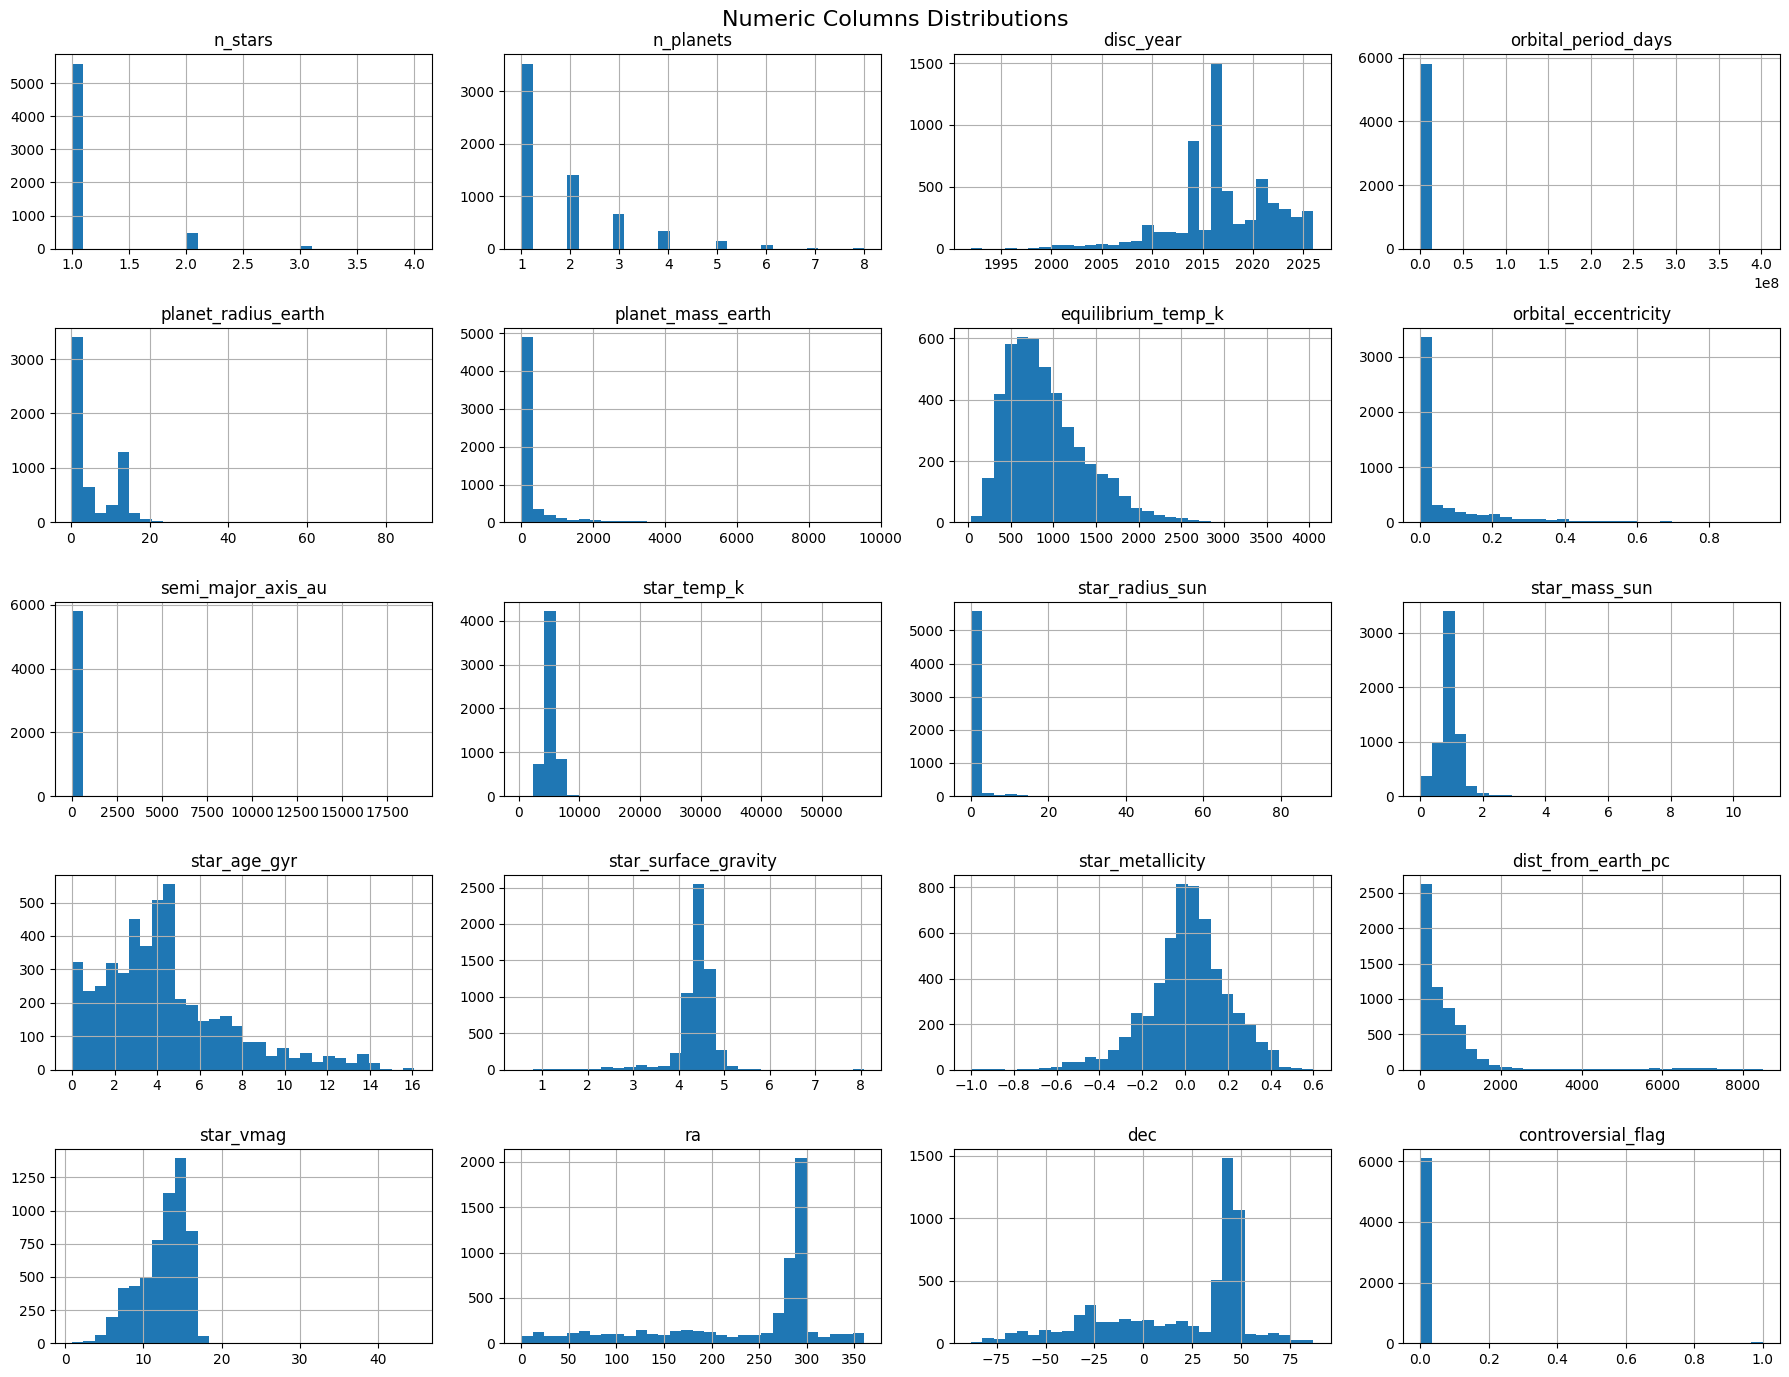

In [23]:
numeric_cols = nasa_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

nasa_df[numeric_cols].hist(
    bins=30,
    figsize=(18, 14)
)

plt.suptitle("Numeric Columns Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
skew_table = (
    nasa_df[numeric_cols]
    .skew(numeric_only=True)
    .sort_values(ascending=False)
    .reset_index()
)

skew_table.columns = ["feature", "skewness"]
skew_table

,feature,skewness
0,orbital_period_days,76.154523
1,semi_major_axis_au,39.396636
2,star_temp_k,15.083237
3,star_radius_sun,13.221139
4,controversial_flag,11.071496
5,star_mass_sun,6.149155
6,planet_mass_earth,4.385545
7,dist_from_earth_pc,3.995273
8,n_stars,3.495885
9,orbital_eccentricity,2.637990


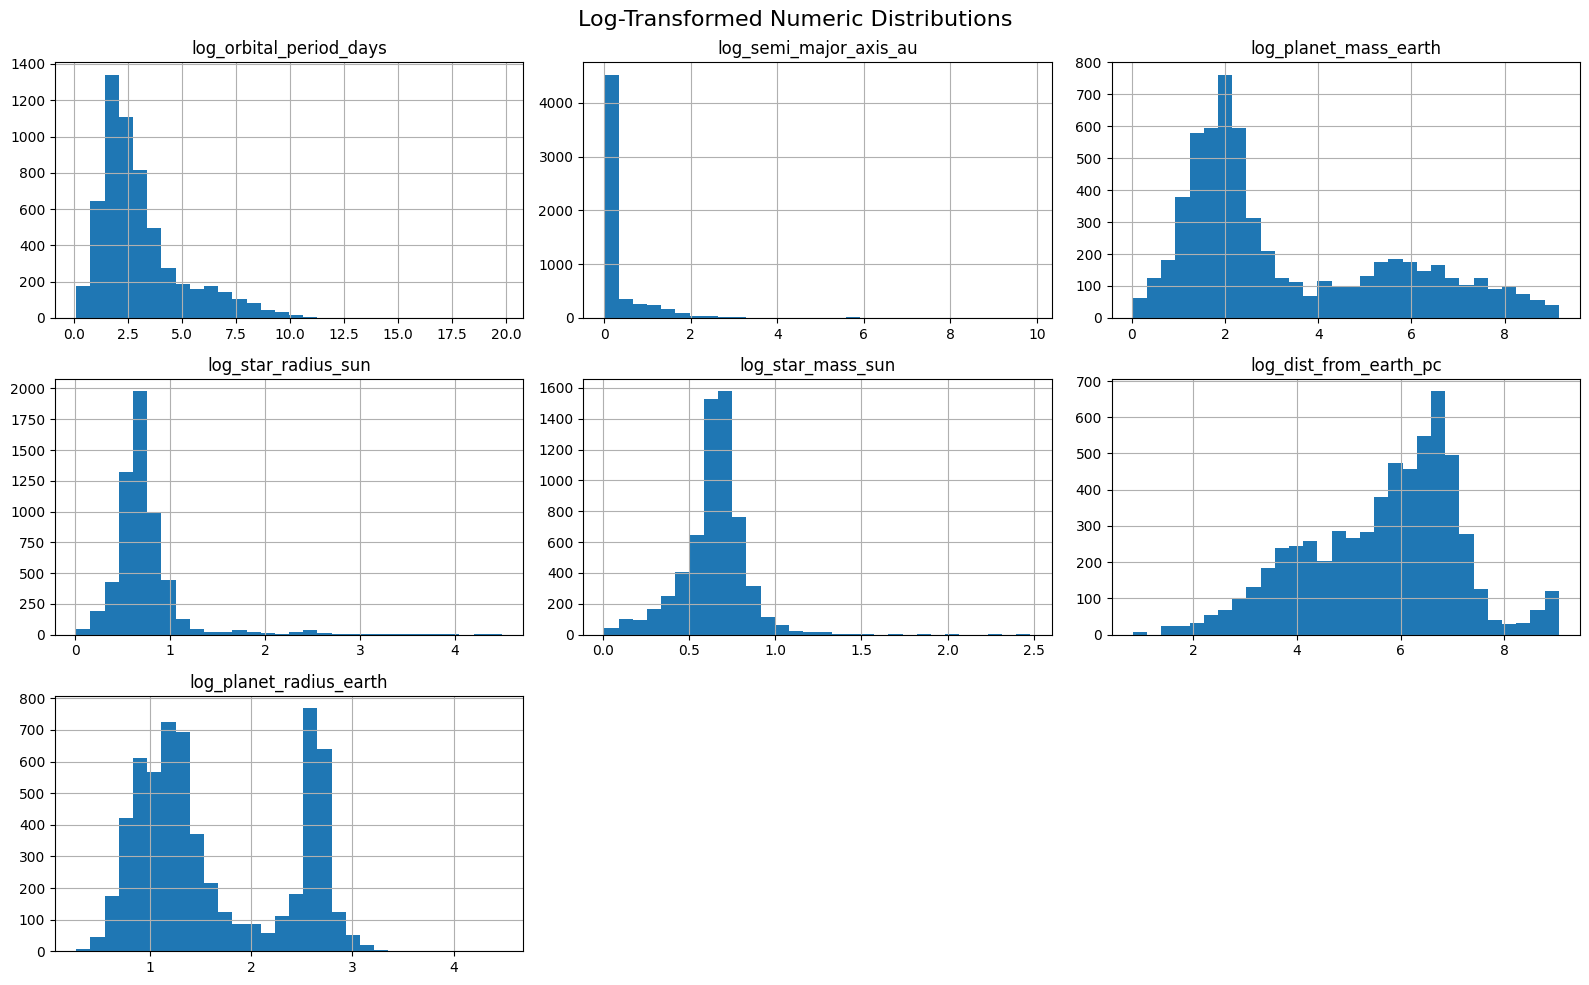

In [26]:
import numpy as np

log_cols = [
    "orbital_period_days",
    "semi_major_axis_au",
    "planet_mass_earth",
    "star_radius_sun",
    "star_mass_sun",
    "dist_from_earth_pc",
    "planet_radius_earth"
]

log_df = nasa_df[log_cols].copy()

for col in log_cols:
    log_df[f"log_{col}"] = np.log1p(log_df[col])

log_df[[f"log_{col}" for col in log_cols]].hist(
    bins=30,
    figsize=(16, 10)
)

plt.suptitle("Log-Transformed Numeric Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [27]:
skew_compare = pd.DataFrame({
    "original_skew": nasa_df[log_cols].skew(),
    "log1p_skew": np.log1p(nasa_df[log_cols]).skew()
}).sort_values("original_skew", ascending=False)

skew_compare

,original_skew,log1p_skew
orbital_period_days,76.154523,1.610393
semi_major_axis_au,39.396636,5.203932
star_radius_sun,13.221139,4.023932
star_mass_sun,6.149155,0.171389
planet_mass_earth,4.385545,0.836451
dist_from_earth_pc,3.995273,-0.388506
planet_radius_earth,1.743745,0.449920


In [29]:
nasa_df.isna().sum()

,0
planet_name,0
host_star,0
n_stars,0
n_planets,0
discovery_method,0
disc_year,1
disc_facility,0
orbital_period_days,334
planet_radius_earth,50
planet_mass_earth,31


# HANDLING WITH DATA

In [31]:
drop_cols = [
    "planet_name",
    "host_star",
    "disc_facility",
    "disc_year",
    "ra",
    "dec",
    "habitable_zone_flag",
    "multi_planet_system",
    "is_recent_discovery",
    "dist_category",
    "star_type",
    "orbital_period_cat"
]

In [33]:
nasa_model_df = nasa_df.copy()

nasa_model_df = nasa_model_df[nasa_model_df["planet_type"] != "Unknown"].copy()

nasa_model_df["planet_type"].value_counts()

,count
planet_type,
Mini-Neptune,2148
Gas Giant,1734
Super-Earth,1185
Neptune-like,479
Super-Jupiter,324
Sub-Earth,230


In [34]:
target_col = "planet_type"

base_feature_cols = [
    "n_stars",
    "n_planets",

    "orbital_period_days",
    "planet_radius_earth",
    "planet_mass_earth",
    "equilibrium_temp_k",
    "orbital_eccentricity",
    "semi_major_axis_au",

    "star_temp_k",
    "star_radius_sun",
    "star_mass_sun",
    "star_age_gyr",
    "star_surface_gravity",
    "star_metallicity",

    "dist_from_earth_pc"
]

# Feature engineering: density-like proxy
nasa_model_df["density_proxy"] = (
    nasa_model_df["planet_mass_earth"] /
    (nasa_model_df["planet_radius_earth"] ** 3)
)

feature_cols = base_feature_cols + ["density_proxy"]

feature_cols

['n_stars',
 'n_planets',
 'orbital_period_days',
 'planet_radius_earth',
 'planet_mass_earth',
 'equilibrium_temp_k',
 'orbital_eccentricity',
 'semi_major_axis_au',
 'star_temp_k',
 'star_radius_sun',
 'star_mass_sun',
 'star_age_gyr',
 'star_surface_gravity',
 'star_metallicity',
 'dist_from_earth_pc',
 'density_proxy']

In [35]:
missing_flag_cols = [
    "equilibrium_temp_k",
    "star_age_gyr",
    "orbital_eccentricity",
    "star_metallicity",
    "orbital_period_days",
    "semi_major_axis_au",
    "star_radius_sun",
    "star_surface_gravity",
    "star_temp_k"
]

for col in missing_flag_cols:
    nasa_model_df[f"{col}_missing"] = nasa_model_df[col].isna().astype(int)

feature_cols = feature_cols + [f"{col}_missing" for col in missing_flag_cols]

feature_cols

['n_stars',
 'n_planets',
 'orbital_period_days',
 'planet_radius_earth',
 'planet_mass_earth',
 'equilibrium_temp_k',
 'orbital_eccentricity',
 'semi_major_axis_au',
 'star_temp_k',
 'star_radius_sun',
 'star_mass_sun',
 'star_age_gyr',
 'star_surface_gravity',
 'star_metallicity',
 'dist_from_earth_pc',
 'density_proxy',
 'equilibrium_temp_k_missing',
 'star_age_gyr_missing',
 'orbital_eccentricity_missing',
 'star_metallicity_missing',
 'orbital_period_days_missing',
 'semi_major_axis_au_missing',
 'star_radius_sun_missing',
 'star_surface_gravity_missing',
 'star_temp_k_missing']

In [36]:
# Check final feature list and missing values before preprocessing

print("Number of selected features:", len(feature_cols))
print("Selected features:")
for col in feature_cols:
    print("-", col)

print("\nMissing values in selected features:")
nasa_model_df[feature_cols].isna().sum().sort_values(ascending=False)

Number of selected features: 25
Selected features:
- n_stars
- n_planets
- orbital_period_days
- planet_radius_earth
- planet_mass_earth
- equilibrium_temp_k
- orbital_eccentricity
- semi_major_axis_au
- star_temp_k
- star_radius_sun
- star_mass_sun
- star_age_gyr
- star_surface_gravity
- star_metallicity
- dist_from_earth_pc
- density_proxy
- equilibrium_temp_k_missing
- star_age_gyr_missing
- orbital_eccentricity_missing
- star_metallicity_missing
- orbital_period_days_missing
- semi_major_axis_au_missing
- star_radius_sun_missing
- star_surface_gravity_missing
- star_temp_k_missing

Missing values in selected features:


,0
equilibrium_temp_k,1525
star_age_gyr,1297
orbital_eccentricity,927
star_metallicity,545
orbital_period_days,331
star_surface_gravity,314
star_radius_sun,310
semi_major_axis_au,308
star_temp_k,289
dist_from_earth_pc,26


In [37]:
model_df = nasa_model_df.copy()

log_cols = [
    "orbital_period_days",
    "semi_major_axis_au",
    "planet_mass_earth",
    "star_radius_sun",
    "star_mass_sun",
    "dist_from_earth_pc",
    "planet_radius_earth",
    "density_proxy"
]

# Safety check: log1p requires non-negative values
model_df[log_cols].min()

,0
orbital_period_days,0.112007
semi_major_axis_au,0.005000
planet_mass_earth,0.020000
star_radius_sun,0.011500
star_mass_sun,0.009400
dist_from_earth_pc,1.301190
planet_radius_earth,0.309800
density_proxy,0.005487


In [38]:
model_df = nasa_model_df.copy()

log_cols = [
    "orbital_period_days",
    "semi_major_axis_au",
    "planet_mass_earth",
    "star_radius_sun",
    "star_mass_sun",
    "dist_from_earth_pc",
    "planet_radius_earth",
    "density_proxy"
]

for col in log_cols:
    model_df[col] = np.log1p(model_df[col])

In [39]:
model_df[log_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
orbital_period_days,5769.0,3.042371,1.980694,0.106166,1.675125,2.492733,3.700298,19.811963
semi_major_axis_au,5792.0,0.375413,0.805072,0.004988,0.050897,0.097081,0.264727,9.852247
planet_mass_earth,6076.0,3.320546,2.257439,0.019803,1.640937,2.317472,5.204902,9.162814
star_radius_sun,5790.0,0.742496,0.409456,0.011434,0.570980,0.668984,0.810930,4.493959
star_mass_sun,6094.0,0.643370,0.185667,0.009356,0.571544,0.662688,0.737164,2.479894
dist_from_earth_pc,6074.0,5.664772,1.478760,0.833426,4.644122,5.949870,6.732920,9.047939
planet_radius_earth,6100.0,1.637225,0.741246,0.269874,1.037003,1.345472,2.564180,4.479674
density_proxy,6076.0,0.475501,0.486052,0.005472,0.217640,0.388334,0.617084,7.831380


In [40]:
X = model_df[feature_cols].copy()
y = model_df["planet_type"].copy()

X.shape, y.shape

((6100, 25), (6100,))

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:")
for idx, cls in enumerate(label_encoder.classes_):
    print(idx, "->", cls)

Classes:
0 -> Gas Giant
1 -> Mini-Neptune
2 -> Neptune-like
3 -> Sub-Earth
4 -> Super-Earth
5 -> Super-Jupiter


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4270, 25)
Validation: (915, 25)
Test: (915, 25)


In [43]:
def class_distribution(y_array, name):
    return pd.Series(
        label_encoder.inverse_transform(y_array)
    ).value_counts(normalize=True).mul(100).round(2).rename(name)

split_dist = pd.concat([
    class_distribution(y_train, "train_%"),
    class_distribution(y_val, "val_%"),
    class_distribution(y_test, "test_%")
], axis=1)

split_dist

,train_%,val_%,test_%
Mini-Neptune,35.22,35.19,35.19
Gas Giant,28.43,28.42,28.42
Super-Earth,19.41,19.45,19.45
Neptune-like,7.85,7.87,7.87
Super-Jupiter,5.32,5.36,5.25
Sub-Earth,3.77,3.72,3.83


In [44]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [45]:
print("Train NaN:", np.isnan(X_train_scaled).sum())
print("Val NaN:", np.isnan(X_val_scaled).sum())
print("Test NaN:", np.isnan(X_test_scaled).sum())

print("Final train shape:", X_train_scaled.shape)
print("Number of classes:", len(label_encoder.classes_))

Train NaN: 0
Val NaN: 0
Test NaN: 0
Final train shape: (4270, 25)
Number of classes: 6


In [47]:
from pathlib import Path
import json
import joblib

processed_dir = Path("processed")
artifacts_dir = Path("artifacts")

processed_dir.mkdir(exist_ok=True)
artifacts_dir.mkdir(exist_ok=True)

# Save processed train/val/test arrays
np.savez(
    processed_dir / "exoplanet_splits_scaled.npz",
    X_train=X_train_scaled,
    X_val=X_val_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test
)

# Save preprocessing objects
joblib.dump(imputer, artifacts_dir / "imputer.pkl")
joblib.dump(scaler, artifacts_dir / "scaler.pkl")
joblib.dump(label_encoder, artifacts_dir / "label_encoder.pkl")

# Save feature/config information
with open(artifacts_dir / "feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=4)

with open(artifacts_dir / "log_columns.json", "w", encoding="utf-8") as f:
    json.dump(log_cols, f, ensure_ascii=False, indent=4)

with open(artifacts_dir / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(label_encoder.classes_.tolist(), f, ensure_ascii=False, indent=4)

# Save planet type info table for the future FastAPI/UI explanation card
planet_type_info_df.to_json(
    artifacts_dir / "planet_type_info.json",
    orient="records",
    force_ascii=False,
    indent=4
)

print("Processed datasets and preprocessing artifacts saved.")

Processed datasets and preprocessing artifacts saved.


In [8]:
with open(artifacts_dir / "ui_feature_config.json", "w", encoding="utf-8") as f:
    json.dump(ui_feature_config, f, ensure_ascii=False, indent=4)

print("Saved:", artifacts_dir / "ui_feature_config.json")

Saved: c:\Users\okani\OneDrive\Masaüstü\pycharm\exoplanet_intelligence\artifacts\ui_feature_config.json


ui_feature_config.json updated with class-friendly ranges.
